In [1]:
import numpy as np
from osgeo import gdal
import matplotlib.pyplot as plt
import os

# ── 원본 dB 파일 읽기 (정규화 전 float32) ────────────────
data_dir = "./copernicus-s1/subset_2_of_subset_1_of_S1C_IW_GRDH_1SDV_Orb_EC_Cal.data"
band_file = os.path.join(data_dir, "Sigma0_VH_db.img")

ds = gdal.Open(band_file)
sigma0_db = ds.GetRasterBand(1).ReadAsArray().astype(np.float32)

# ── NoData 마스크 ─────────────────────────────────────────
nodata_mask = np.isnan(sigma0_db) | np.isinf(sigma0_db) | (sigma0_db < -60)
valid = sigma0_db[~nodata_mask]

# ── 참조값 정의 ───────────────────────────────────────────
reference = {
    "Calm open water":      (-30, -25),
    "Wet bare soil":        (-23, -18),
    "Dry grassland":        (-20, -15),
    "Mature crop":          (-16, -12),
    "Dense forest":         (-12,  -8),
    "Urban fabric":         (-12,  -8),
    "Ship/metal structure": (  3,  12),
}

d:\Project-Sentinel12\.venv_py312\Lib\site-packages\osgeo\gdal.py:330: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


In [4]:
# ── 1. 전체 분포 통계 출력 ────────────────────────────────
print("=" * 55)
print(f"{'전체 유효 픽셀 통계':^55}")
print("=" * 55)
print(f"  픽셀 수:  {len(valid):,}")
print(f"  Min:      {valid.min():.2f} dB")
print(f"  Max:      {valid.max():.2f} dB")
print(f"  Mean:     {valid.mean():.2f} dB")
print(f"  Median:   {np.median(valid):.2f} dB")
print(f"  Std:      {valid.std():.2f} dB")

# ── 2. 참조 범위별 픽셀 비율 ─────────────────────────────
print("\n" + "=" * 55)
print(f"{'Surface Type':<28} {'Range':>12}  {'픽셀 비율':>8}")
print("-" * 55)
for label, (lo, hi) in reference.items():
    count = ((valid >= lo) & (valid <= hi)).sum()
    ratio = 100 * count / len(valid)
    print(f"  {label:<26} [{lo:4d}~{hi:3d} dB]  {ratio:6.2f}%")

# ── 3.  주어진 이미지 픽셀 분포  ────────────────────────────
print("\n" + "=" * 55)
print(f"{'Sigma0_VH_dB 구간별 픽셀 분포':^55}")
print("-" * 55)
bins = [-60, -40, -35, -30, -25, -20, -15, -12, -8, -5, 0, 5, 15]
hist, edges = np.histogram(valid, bins=bins)
for i in range(len(hist)):
    bar = "█" * int(hist[i] / len(valid) * 200)
    pct = 100 * hist[i] / len(valid)
    print(f"  [{edges[i]:5.0f}~{edges[i+1]:4.0f} dB] {pct:5.1f}% {bar}")


                      전체 유효 픽셀 통계                      
  픽셀 수:  1,002,001
  Min:      -41.94 dB
  Max:      10.75 dB
  Mean:     -27.46 dB
  Median:   -29.68 dB
  Std:      5.91 dB

Surface Type                        Range     픽셀 비율
-------------------------------------------------------
  Calm open water            [ -30~-25 dB]   31.75%
  Wet bare soil              [ -23~-18 dB]    9.66%
  Dry grassland              [ -20~-15 dB]   12.32%
  Mature crop                [ -16~-12 dB]    5.89%
  Dense forest               [ -12~ -8 dB]    1.17%
  Urban fabric               [ -12~ -8 dB]    1.17%
  Ship/metal structure       [   3~ 12 dB]    0.00%

                Sigma0_VH_dB 구간별 픽셀 분포                 
-------------------------------------------------------
  [  -60~ -40 dB]   0.0% 
  [  -40~ -35 dB]   0.9% █
  [  -35~ -30 dB]  44.0% ████████████████████████████████████████████████████████████████████████████████████████
  [  -30~ -25 dB]  31.7% ████████████████████████████████████████

OSError: [Errno 22] Invalid argument: 'vh_db_vs_reference.png'

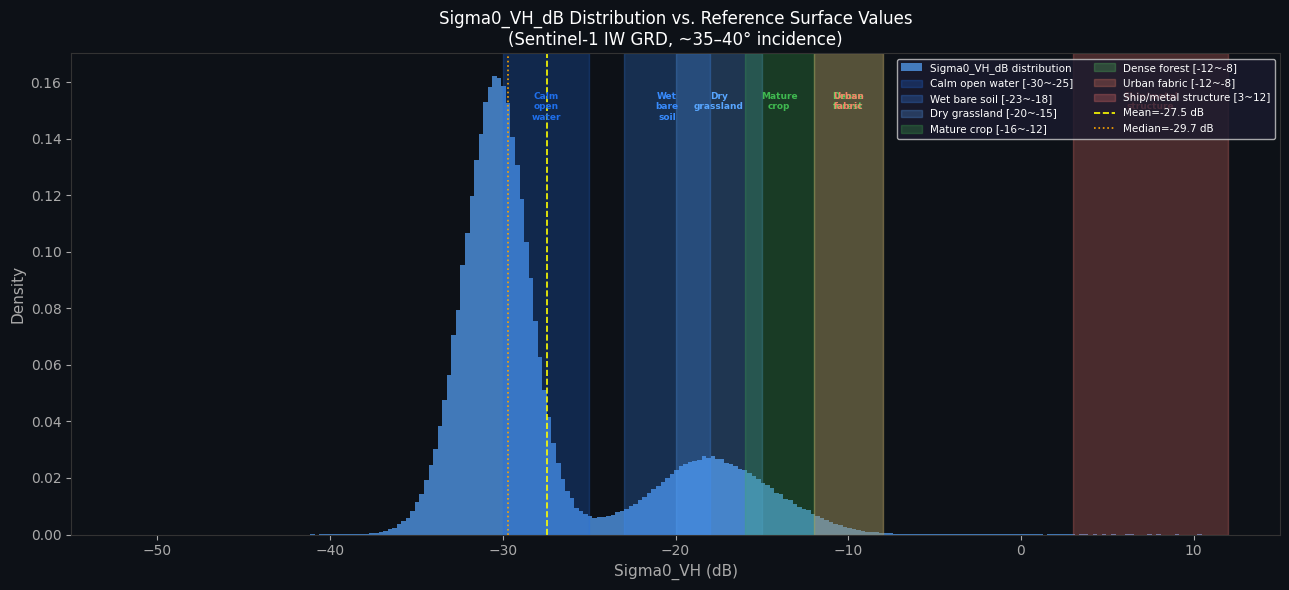

In [3]:
# import matplotlib
# matplotlib.use('Agg')

# ── 4. 히스토그램 + 참조 범위 시각화 ─────────────────────
fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')

# 히스토그램
ax.hist(valid, bins=200, color='#58a6ff', alpha=0.7,
        density=True, label='Sigma0_VH_dB distribution')

# 참조 범위 오버레이
colors = ['#1f6feb','#388bfd','#58a6ff',
          '#3fb950','#56d364','#f78166','#ff7b72']
y_max = ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 0.1

for (label, (lo, hi)), color in zip(reference.items(), colors):
    ax.axvspan(lo, hi, alpha=0.25, color=color, label=f"{label} [{lo}~{hi}]")
    ax.text((lo + hi) / 2, y_max * 0.92,
            label.replace(" ", "\n"), fontsize=6.5,
            ha='center', va='top', color=color, fontweight='bold')

ax.axvline(valid.mean(), color='yellow', linestyle='--',
           linewidth=1.2, label=f'Mean={valid.mean():.1f} dB')
ax.axvline(np.median(valid), color='orange', linestyle=':',
           linewidth=1.2, label=f'Median={np.median(valid):.1f} dB')

ax.set_xlabel('Sigma0_VH (dB)', color='#aaa', fontsize=11)
ax.set_ylabel('Density', color='#aaa', fontsize=11)
ax.set_title('Sigma0_VH_dB Distribution vs. Reference Surface Values\n(Sentinel-1 IW GRD, ~35–40° incidence)',
             color='white', fontsize=12)
ax.tick_params(colors='#aaa')
ax.set_xlim(-55, 15)
for spine in ax.spines.values():
    spine.set_edgecolor('#333')
ax.legend(fontsize=7.5, facecolor='#1a1a2e', labelcolor='white',
          loc='upper right', ncol=2)

plt.tight_layout()
plt.savefig('vh_db_vs_reference.png', dpi=130,
            bbox_inches='tight', facecolor='#0d1117')
plt.close()
print("\n히스토그램 저장: vh_db_vs_reference.png")

In [18]:
# ── 5. 선박 탐지 관점 요약 ───────────────────────────────
ship_lo, ship_hi = 3, 12
sea_lo,  sea_hi  = -30, -25

ship_pixels = ((valid >= ship_lo) & (valid <= ship_hi)).sum()
sea_pixels  = ((valid >= sea_lo)  & (valid <= sea_hi)).sum()

print("\n" + "=" * 55)
print(f"{'선박 탐지 관점 요약':^55}")
print("=" * 55)
print(f"  해수면 범위 [{sea_lo}~{sea_hi} dB]: "
      f"{sea_pixels:,} px ({100*sea_pixels/len(valid):.2f}%)")
print(f"  선박 범위   [{ship_lo}~{ship_hi} dB]: "
      f"{ship_pixels:,} px ({100*ship_pixels/len(valid):.2f}%)")
print(f"\n  ※ 선박 픽셀이 0%에 가까우면 정상")
print(f"     (선박은 전체 이미지에서 극소수)")
print(f"  ※ 해수면 픽셀 비율이 바다 면적 비율과")
print(f"     대략 일치하면 Calibration 정상")


                      선박 탐지 관점 요약                      
  해수면 범위 [-30~-25 dB]: 318,129 px (31.75%)
  선박 범위   [3~12 dB]: 39 px (0.00%)

  ※ 선박 픽셀이 0%에 가까우면 정상
     (선박은 전체 이미지에서 극소수)
  ※ 해수면 픽셀 비율이 바다 면적 비율과
     대략 일치하면 Calibration 정상
